In [70]:
import random
import uuid
from sklearn.isotonic import IsotonicRegression
from faker import Faker

fk = Faker()

nsamples = 10000
y = [random.random() > 0.5 for _ in range(nsamples)]
method_scores = [
    {'uuid': str(uuid.uuid4()), 
     'method': 'm1', 
     'field': 'patient_name', 
     'value': fk.first_name(), 
     'score':  random.random()}
    for i in range(nsamples)]
scores = [mscr['score'] for mscr in method_scores]
iso_reg = IsotonicRegression().fit(scores, y)
new_scores = iso_reg.predict(scores)

In [71]:
method_scores

[{'uuid': 'b019e2ac-f012-4dd5-8f1c-bdead16cc164',
  'method': 'm1',
  'field': 'patient_name',
  'value': 'Victor',
  'score': 0.35116069515080817},
 {'uuid': '6f92d30a-220d-4343-b006-8f067f408ade',
  'method': 'm1',
  'field': 'patient_name',
  'value': 'Michael',
  'score': 0.9590396660616579},
 {'uuid': 'c4c17560-43f3-46ff-9abf-68e3eab34e48',
  'method': 'm1',
  'field': 'patient_name',
  'value': 'Brian',
  'score': 0.9601058483734368},
 {'uuid': '91b1f0b8-320e-471e-bdda-31136755986d',
  'method': 'm1',
  'field': 'patient_name',
  'value': 'George',
  'score': 0.4952221877885852},
 {'uuid': '86e8bf83-4b14-439e-8a2d-7627b45260a9',
  'method': 'm1',
  'field': 'patient_name',
  'value': 'Dana',
  'score': 0.8595618754989258},
 {'uuid': 'ed9780cb-be1b-408b-b3e5-5e5f4b63a66b',
  'method': 'm1',
  'field': 'patient_name',
  'value': 'Roger',
  'score': 0.2464720029119123},
 {'uuid': 'c166de72-174c-4c7a-8c7b-cb30fecb4258',
  'method': 'm1',
  'field': 'patient_name',
  'value': 'Jody',


In [72]:
from sklearn.metrics import roc_auc_score, precision_recall_curve

auc_scores = roc_auc_score(y, scores)
auc_new_scores = roc_auc_score(y, new_scores)
print('auc after calibration = ', auc_new_scores)
print('auc before calibration = ', auc_scores)


auc after calibration =  0.5071117527770269
auc before calibration =  0.5008030960007004


In [73]:
prec, rec, th = precision_recall_curve(y, scores)
nprec, nrec, nth = precision_recall_curve(y, new_scores)

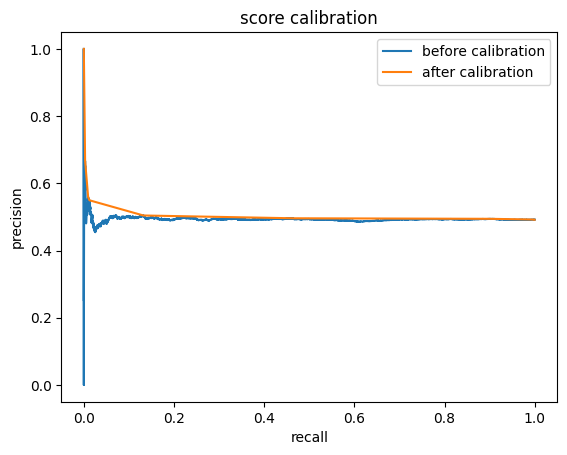

In [75]:
import matplotlib.pyplot as plt
plt.figure()
plt.plot(rec, prec, label='before calibration')
plt.plot(nrec, nprec, label='after calibration')
plt.xlabel('recall')
plt.ylabel('precision')
plt.title('score calibration')
plt.legend()
plt.show()